<a href="https://colab.research.google.com/github/mGarbowski/zzsn-projekt/blob/heatmap/notebooks/05-saliency.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Wizualizacja cech
* Przy generacji obrazka, w każdym kroku czasowym wyznaczamy za pomocą kodera cechy per patch
* Wizualizacja dla wybranych cech dla kilku kroków czasowych
* Aktualnie notatnik ma charakter demonstracyjny, powtórzymy wizualizację dla porządnie wytrenowanego modelu i odpowiednio wybranych cech

## Setup

In [1]:
!git clone https://github.com/mGarbowski/zzsn-projekt.git
!cd zzsn-projekt && git checkout heatmap

Cloning into 'zzsn-projekt'...
remote: Enumerating objects: 514, done.
remote: Counting objects: 100% (249/249), done.
remote: Compressing objects: 100% (151/151), done.
remote: Total 514 (delta 115), reused 202 (delta 96), pack-reused 265 (from 1)
Receiving objects: 100% (514/514), 12.76 MiB | 18.14 MiB/s, done.
Resolving deltas: 100% (251/251), done.
Branch 'heatmap' set up to track remote branch 'heatmap' from 'origin'.
Switched to a new branch 'heatmap'


In [2]:
import os
os.chdir("zzsn-projekt")
os.getcwd()

'/content/zzsn-projekt'

In [3]:
!wandb login

wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter: 
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: mikolaj-garbowski (mikolaj-garbowski-warsaw-university-of-technology) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


## Demo

In [4]:
from models.diffusion import WrappedDiffusion, GenerationParams
from models.heatmap import overlay_heatmap
import matplotlib.pyplot as plt
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


In [ ]:
wrapped_diffusion = WrappedDiffusion.from_pretrained(
    schmidhuber_artifact_id="mikolaj-garbowski-warsaw-university-of-technology/zzsn-projekt/model-ms3nxq87-epoch_2:v0",
    device=device,
    torch_dtype=torch.float16,
    safety_checker=None,
)

In [ ]:
params = GenerationParams(
    prompts=["A picture of a british shorthair cat in cartoon style"],
    num_seeds=1,
    num_inference_steps=50,
    guidance_scale=7.5,
)
results = wrapped_diffusion.generate_and_collect_heatmaps(params, features_to_collect=[0, 1, 2])

In [17]:
len(results)

1

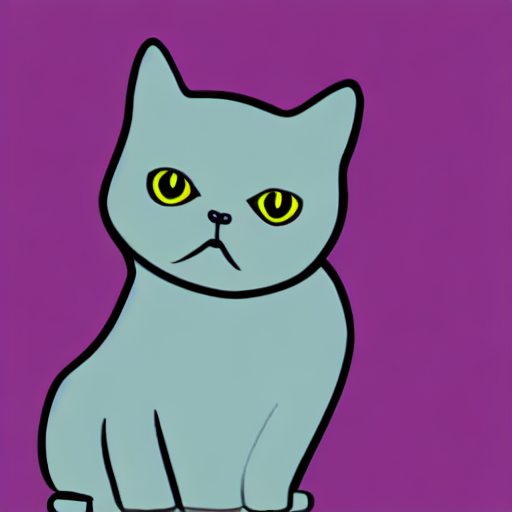

In [8]:
results[0][0].image

In [18]:
results[0][1].shape

torch.Size([3, 51, 16, 16])

In [13]:
def show_feature(feature_idx):
  generation, heatmaps_tensor = results[0]
  _ = overlay_heatmap(generation.image, heatmaps_tensor[feature_idx], timesteps=[0, 10, 20, 30, 40, 50], cols=3)


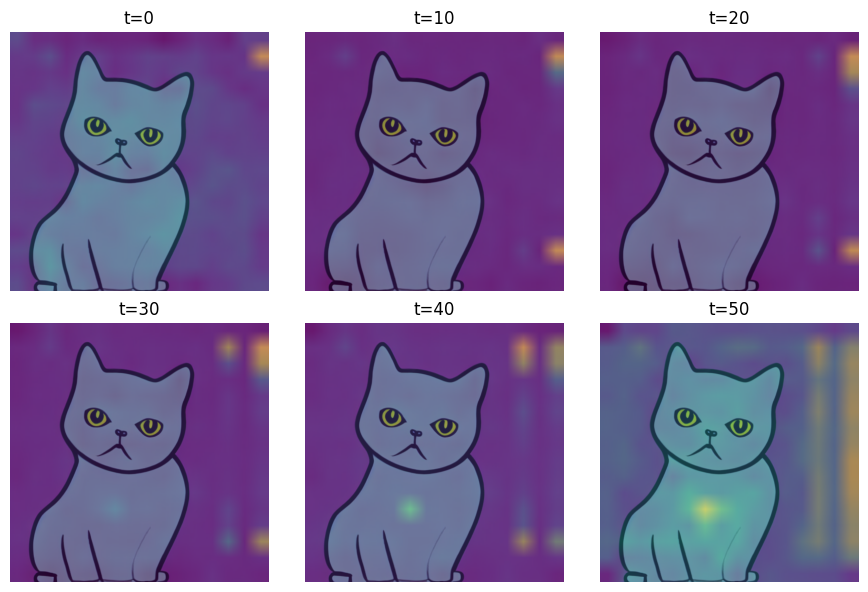

In [14]:
show_feature(0)

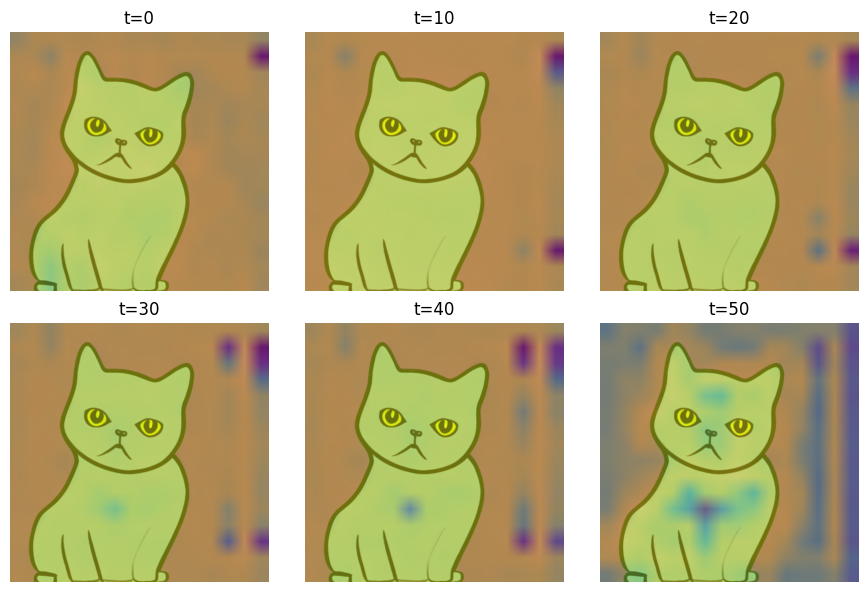

In [15]:
show_feature(1)

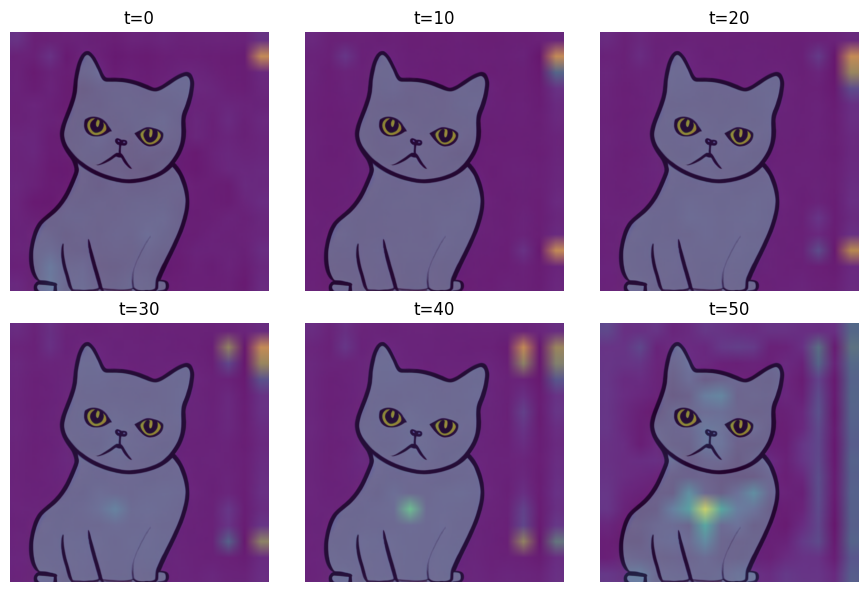

In [16]:
show_feature(2)